In [46]:
!pip install fastparquet
!pip install matplotlib

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_parquet('yellow_tripdata_2020-07.parquet', engine='fastparquet')
do = df = pd.read_parquet('yellow_tripdata_2020-07.parquet', engine='fastparquet')

df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2020-07-01 00:25:32,2020-07-01 00:33:39,1.0,1.50,1.0,N,238,75,2,8.0,0.5,0.5,0.00,0.0,0.3,9.30,0.0,NaN
1,1,2020-07-01 00:03:19,2020-07-01 00:25:43,1.0,9.50,1.0,N,138,216,1,26.5,0.5,0.5,0.00,0.0,0.3,27.80,0.0,NaN
2,2,2020-07-01 00:15:11,2020-07-01 00:29:24,1.0,5.85,1.0,N,230,88,2,18.5,0.5,0.5,0.00,0.0,0.3,22.30,2.5,NaN
3,2,2020-07-01 00:30:49,2020-07-01 00:38:26,1.0,1.90,1.0,N,88,232,1,8.0,0.5,0.5,2.36,0.0,0.3,14.16,2.5,NaN
4,2,2020-07-01 00:31:26,2020-07-01 00:38:02,1.0,1.25,1.0,N,37,17,2,6.5,0.5,0.5,0.00,0.0,0.3,7.80,0.0,NaN
5,1,2020-07-01 00:09:00,2020-07-01 00:34:39,1.0,9.70,1.0,N,140,61,1,30.0,3.0,0.5,0.00,0.0,0.3,33.80,2.5,NaN
6,2,2020-07-01 00:44:08,2020-07-01 00:58:12,1.0,5.27,1.0,N,137,260,1,16.5,0.5,0.5,6.09,0.0,0.3,26.39,2.5,NaN
7,2,2020-07-01 00:49:20,2020-07-01 00:56:44,1.0,1.32,1.0,N,166,41,2,7.5,0.5,0.5,0.00,0.0,0.3,8.80,0.0,NaN
8,2,2020-07-01 00:21:59,2020-07-01 00:25:12,1.0,0.73,1.0,N,239,142,1,5.0,0.5,0.5,1.32,0.0,0.3,10.12,2.5,NaN
9,2,2020-07-01 00:08:28,2020-07-01 00:36:18,1.0,18.65,2.0,N,132,249,1,52.0,0.0,0.5,11.06,0.0,0.3,66.36,2.5,NaN


In [48]:
col = 'fare_amount'
df[col].unique()

df[col].sort_values()

,fare_amount
78485,-391.50
377409,-350.00
257238,-281.00
368459,-259.50
561326,-175.00
...,...
310088,703.50
377408,850.00
664007,999.08
99235,1091.00


In [49]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [50]:
# Calcular duração da viagem
df['trip_duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']

# Converter duração para minutos
df['trip_duration_minutes'] = df['trip_duration'].dt.total_seconds() / 60

In [51]:
df = df[df['total_amount'] >= 0] # Remover Valores Pagos Negativos (3697) - (800412 pra 796715 linhas)


# Verificaçãooo df[(df['trip_duration_minutes'] > 60) & (df['trip_distance'] == 0)].sort_values(by='trip_duration_minutes', ascending=False)
mais_uma_hora_parado = df[(df['trip_duration_minutes'] > 60) & (df['trip_distance'] == 0)]
df = df.drop(mais_uma_hora_parado.index) # Removendo os paradões por mais de uma hora (695)

# Removendo Passageiros Estranhos
df = df[df['passenger_count'] >= 1]
df = df[df['passenger_count'].isna() == False] # Passageiros Nulos (62838)

# Removendo viagens com mais de 150 distancia (8)
mais_150_distancia = df[df['trip_distance'] > 150]
df = df.drop(mais_150_distancia.index)

# Removendo viagens com mais de 500 total (12)
mais_500_total = df[df['total_amount'] > 500]
df = df.drop(mais_500_total.index)

# Removendo viagens com valor 0 (255)
viagem_gratis = df[df['total_amount'] == 0]
df = df.drop(viagem_gratis.index)

# Removendo viagens com mais de 3 horas (1424)
maior_3_horas = df[df['trip_duration_minutes'] > 180]
df = df.drop(maior_3_horas.index)

<Axes: >

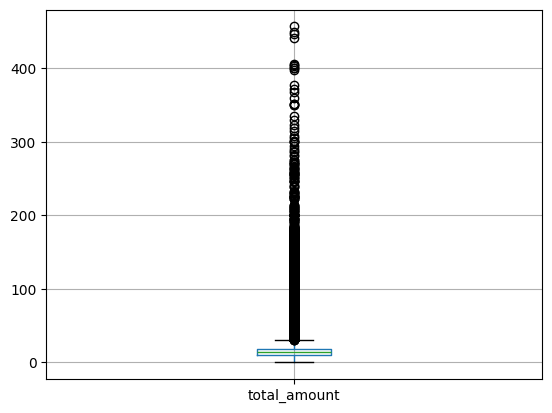

In [52]:
df.boxplot(column = ['total_amount'])

In [53]:
df['total_amount'].sort_values(ascending=False)

,total_amount
393998,457.34
678518,450.30
593616,447.55
36887,440.80
585143,406.05
...,...
636583,0.30
305543,0.30
636584,0.30
239683,0.30


Text(0, 0.5, 'Viagens')

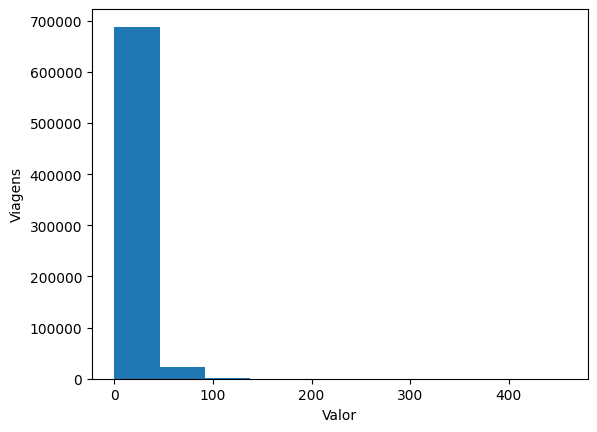

In [54]:
plt.hist(df['total_amount'], bins = 10)
plt.xlabel ('Valor')
plt.ylabel ('Viagens')

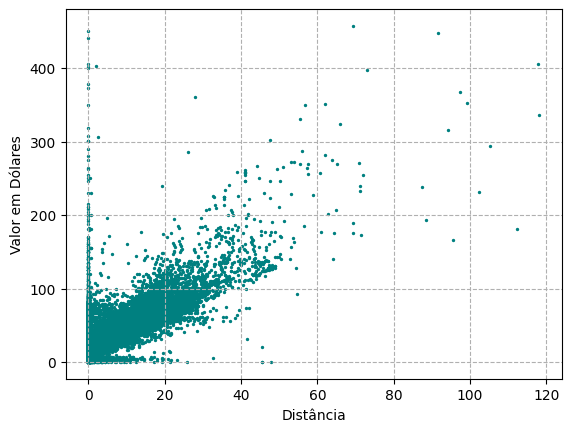

In [55]:
scatter = df.plot.scatter(x='trip_distance', y='total_amount', s=2, c='teal')
scatter.set_xlabel('Distância')
scatter.set_ylabel('Valor em Dólares')
plt.grid(linestyle = 'dashed')
plt.show()

In [56]:
df[df['passenger_count'] == 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration,trip_duration_minutes


In [57]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration,trip_duration_minutes
0,1,2020-07-01 00:25:32,2020-07-01 00:33:39,1.0,1.50,1.0,N,238,75,2,...,0.5,0.5,0.00,0.0,0.3,9.30,0.0,NaN,0 days 00:08:07,8.116667
1,1,2020-07-01 00:03:19,2020-07-01 00:25:43,1.0,9.50,1.0,N,138,216,1,...,0.5,0.5,0.00,0.0,0.3,27.80,0.0,NaN,0 days 00:22:24,22.400000
2,2,2020-07-01 00:15:11,2020-07-01 00:29:24,1.0,5.85,1.0,N,230,88,2,...,0.5,0.5,0.00,0.0,0.3,22.30,2.5,NaN,0 days 00:14:13,14.216667
3,2,2020-07-01 00:30:49,2020-07-01 00:38:26,1.0,1.90,1.0,N,88,232,1,...,0.5,0.5,2.36,0.0,0.3,14.16,2.5,NaN,0 days 00:07:37,7.616667
4,2,2020-07-01 00:31:26,2020-07-01 00:38:02,1.0,1.25,1.0,N,37,17,2,...,0.5,0.5,0.00,0.0,0.3,7.80,0.0,NaN,0 days 00:06:36,6.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737560,2,2020-07-31 23:44:28,2020-07-31 23:56:08,1.0,5.28,1.0,N,138,53,1,...,0.5,0.5,5.19,0.0,0.3,22.49,0.0,NaN,0 days 00:11:40,11.666667
737561,2,2020-07-31 23:43:29,2020-07-31 23:49:49,1.0,1.75,1.0,N,148,87,1,...,0.5,0.5,2.26,0.0,0.3,13.56,2.5,NaN,0 days 00:06:20,6.333333
737562,2,2020-07-31 23:31:12,2020-07-31 23:52:17,1.0,14.02,1.0,N,132,16,2,...,0.5,0.5,0.00,0.0,0.3,39.30,0.0,NaN,0 days 00:21:05,21.083333
737563,2,2020-07-31 23:04:12,2020-07-31 23:06:52,1.0,0.93,1.0,N,263,140,1,...,0.5,0.5,1.50,0.0,0.3,9.80,2.5,NaN,0 days 00:02:40,2.666667


In [58]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration,trip_duration_minutes
count,711988.000000,711988,711988,711988.000000,711988.000000,711988.000000,711988.000000,711988.000000,711988.000000,711988.000000,711988.000000,711988.000000,711988.000000,711988.000000,711988.000000,711988.000000,711988.000000,0.0,711988,711988.000000
mean,1.637772,2020-07-17 14:33:50.222562816,2020-07-17 14:44:33.151894528,1.416219,2.710087,1.038553,162.384455,157.819601,1.340919,11.761009,1.057639,0.497254,1.775019,0.210325,0.299820,17.010540,2.168149,NaN,0 days 00:10:42.929331674,10.715489
min,1.000000,2008-12-31 23:12:22,2008-12-31 23:25:04,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-0.500000,0.000000,0.000000,0.000000,0.000000,0.110000,0.000000,NaN,-366 days +00:36:01,-527003.983333
25%,1.000000,2020-07-09 17:09:41.249999872,2020-07-09 17:23:25.750000128,1.000000,0.980000,1.000000,113.000000,100.000000,1.000000,6.000000,0.000000,0.500000,0.000000,0.000000,0.300000,10.560000,2.500000,NaN,0 days 00:05:26,5.433333
50%,2.000000,2020-07-17 17:22:55,2020-07-17 17:36:57,1.000000,1.700000,1.000000,161.000000,161.000000,1.000000,8.500000,0.500000,0.500000,1.560000,0.000000,0.300000,13.560000,2.500000,NaN,0 days 00:08:59,8.983333
75%,2.000000,2020-07-25 11:23:18.750000128,2020-07-25 11:32:34.750000128,1.000000,3.000000,1.000000,234.000000,234.000000,2.000000,13.000000,2.500000,0.500000,2.650000,0.000000,0.300000,18.800000,2.500000,NaN,0 days 00:14:29,14.483333
max,2.000000,2020-08-01 00:03:40,2020-08-01 00:44:51,9.000000,118.070000,99.000000,265.000000,265.000000,4.000000,450.000000,47.400000,3.300000,288.400000,126.120000,0.300000,457.340000,2.500000,NaN,0 days 02:58:27,178.450000
std,0.480645,NaN,NaN,1.028811,3.361766,0.852566,67.510830,72.545979,0.499520,10.446387,1.236421,0.037247,2.375189,1.277364,0.007345,12.076013,0.848233,NaN,0 days 10:24:58.266483351,624.971108


In [59]:
df['day_week'] = df['tpep_pickup_datetime'].dt.dayofweek

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Segunda-Feira'),
  Text(1, 0, 'Terça-Feira'),
  Text(2, 0, 'Quarta-Feira'),
  Text(3, 0, 'Quinta-Feira'),
  Text(4, 0, 'Sexta-Feira'),
  Text(5, 0, 'Sábado'),
  Text(6, 0, 'Domingo')])

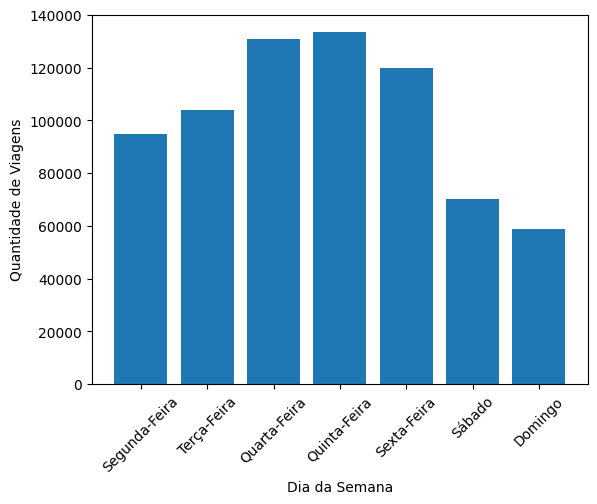

In [60]:
weekday = df['day_week'].value_counts().sort_index()
name = ['Segunda-Feira', 'Terça-Feira', 'Quarta-Feira', 'Quinta-Feira', 'Sexta-Feira', 'Sábado', 'Domingo']
plt.bar(name, weekday)
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade de Viagens')
plt.xticks(rotation = 45)

(array([-50.,   0.,  50., 100., 150., 200., 250., 300.]),
 [Text(-50.0, 0, '−50'),
  Text(0.0, 0, '0'),
  Text(50.0, 0, '50'),
  Text(100.0, 0, '100'),
  Text(150.0, 0, '150'),
  Text(200.0, 0, '200'),
  Text(250.0, 0, '250'),
  Text(300.0, 0, '300')])

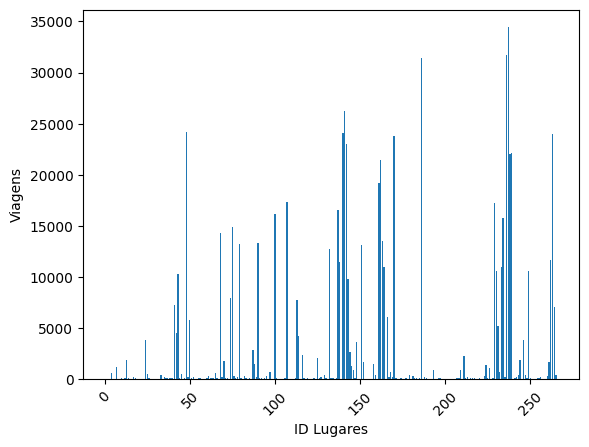

In [61]:
engaged = df['PULocationID'].value_counts().sort_index()
plt.bar(engaged.index, engaged)
plt.xlabel('ID Lugares')
plt.ylabel('Viagens')
plt.xticks(rotation = 45)

(array([-50.,   0.,  50., 100., 150., 200., 250., 300.]),
 [Text(-50.0, 0, '−50'),
  Text(0.0, 0, '0'),
  Text(50.0, 0, '50'),
  Text(100.0, 0, '100'),
  Text(150.0, 0, '150'),
  Text(200.0, 0, '200'),
  Text(250.0, 0, '250'),
  Text(300.0, 0, '300')])

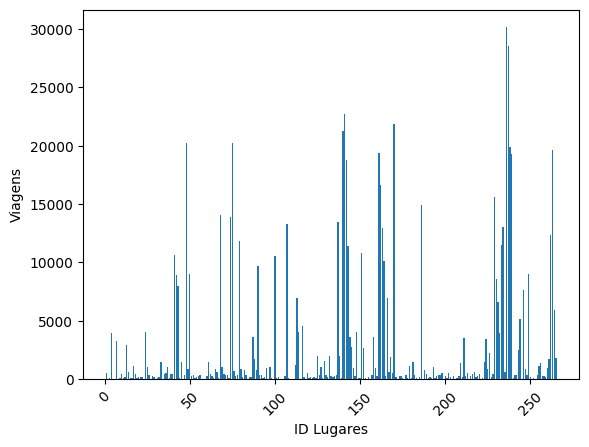

In [62]:
disengaged = df['DOLocationID'].value_counts().sort_index()
plt.bar(disengaged.index, disengaged)
plt.xlabel('ID Lugares')
plt.ylabel('Viagens')
plt.xticks(rotation = 45)

In [63]:
#paytype =
df['payment_type'].unique()


array([2, 1, 4, 3])

In [64]:
do[do['payment_type'] == 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration,trip_duration_minutes
737565,2,2020-07-01 00:10:56,2020-07-01 00:27:22,NaN,7.41,NaN,None,137,69,0,...,0.00,0.0,2.75,0.00,0.3,35.59,NaN,NaN,0 days 00:16:26,16.433333
737566,2,2020-07-01 00:22:00,2020-07-01 00:35:00,NaN,3.90,NaN,None,148,17,0,...,0.00,0.5,2.00,0.00,0.3,22.09,NaN,NaN,0 days 00:13:00,13.000000
737567,2,2020-07-01 00:57:25,2020-07-01 01:22:13,NaN,16.17,NaN,None,158,29,0,...,0.00,0.5,0.00,6.12,0.3,62.70,NaN,NaN,0 days 00:24:48,24.800000
737568,2,2020-07-01 00:37:27,2020-07-01 00:45:43,NaN,2.99,NaN,None,137,232,0,...,0.00,0.5,1.84,0.00,0.3,25.50,NaN,NaN,0 days 00:08:16,8.266667
737569,2,2020-07-01 00:57:00,2020-07-01 01:24:00,NaN,11.90,NaN,None,41,248,0,...,0.00,0.5,0.00,0.00,0.3,51.90,NaN,NaN,0 days 00:27:00,27.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
800407,2,2020-07-31 23:07:17,2020-07-31 23:13:11,NaN,1.24,NaN,None,91,71,0,...,0.00,0.5,2.75,0.00,0.3,18.50,NaN,NaN,0 days 00:05:54,5.900000
800408,2,2020-07-31 23:11:00,2020-07-31 23:27:00,NaN,3.36,NaN,None,78,213,0,...,0.00,0.5,2.75,0.00,0.3,23.58,NaN,NaN,0 days 00:16:00,16.000000
800409,2,2020-07-31 23:57:00,2020-08-01 00:18:00,NaN,4.98,NaN,None,159,32,0,...,0.00,0.5,2.75,0.00,0.3,30.32,NaN,NaN,0 days 00:21:00,21.000000
800410,6,2020-07-31 23:07:02,2020-08-01 00:08:03,NaN,4.45,NaN,None,265,50,0,...,1.47,0.5,0.00,0.00,0.3,21.58,NaN,NaN,0 days 01:01:01,61.016667


In [65]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration,trip_duration_minutes,day_week
0,1,2020-07-01 00:25:32,2020-07-01 00:33:39,1.0,1.50,1.0,N,238,75,2,...,0.5,0.00,0.0,0.3,9.30,0.0,NaN,0 days 00:08:07,8.116667,2
1,1,2020-07-01 00:03:19,2020-07-01 00:25:43,1.0,9.50,1.0,N,138,216,1,...,0.5,0.00,0.0,0.3,27.80,0.0,NaN,0 days 00:22:24,22.400000,2
2,2,2020-07-01 00:15:11,2020-07-01 00:29:24,1.0,5.85,1.0,N,230,88,2,...,0.5,0.00,0.0,0.3,22.30,2.5,NaN,0 days 00:14:13,14.216667,2
3,2,2020-07-01 00:30:49,2020-07-01 00:38:26,1.0,1.90,1.0,N,88,232,1,...,0.5,2.36,0.0,0.3,14.16,2.5,NaN,0 days 00:07:37,7.616667,2
4,2,2020-07-01 00:31:26,2020-07-01 00:38:02,1.0,1.25,1.0,N,37,17,2,...,0.5,0.00,0.0,0.3,7.80,0.0,NaN,0 days 00:06:36,6.600000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737560,2,2020-07-31 23:44:28,2020-07-31 23:56:08,1.0,5.28,1.0,N,138,53,1,...,0.5,5.19,0.0,0.3,22.49,0.0,NaN,0 days 00:11:40,11.666667,4
737561,2,2020-07-31 23:43:29,2020-07-31 23:49:49,1.0,1.75,1.0,N,148,87,1,...,0.5,2.26,0.0,0.3,13.56,2.5,NaN,0 days 00:06:20,6.333333,4
737562,2,2020-07-31 23:31:12,2020-07-31 23:52:17,1.0,14.02,1.0,N,132,16,2,...,0.5,0.00,0.0,0.3,39.30,0.0,NaN,0 days 00:21:05,21.083333,4
737563,2,2020-07-31 23:04:12,2020-07-31 23:06:52,1.0,0.93,1.0,N,263,140,1,...,0.5,1.50,0.0,0.3,9.80,2.5,NaN,0 days 00:02:40,2.666667,4
